# Tutorial 4 — Optimized BYOL Pretraining with YOLO26 Segmentation

**Course:** CSE445 — Computer Vision  
**Instructor:** Dr Mohammad Rifat Ahmmad Rashid  

**Dataset:** Brain Tumor Image Dataset — Semantic Segmentation  
**Kaggle source:** `pkdarabi/brain-tumor-image-dataset-semantic-segmentation`

**Pipeline:** MRI images without labels → BYOL pretraining of the YOLO26 feature extractor → supervised YOLO26 segmentation fine-tuning → mask evaluation and interpretation.

This notebook implements **Bootstrap Your Own Latent (BYOL)** with YOLO26. BYOL uses an online network and a slowly updated target network. Unlike SimCLR and MoCo, it does not require explicit negative examples.

The implementation includes progress bars, mixed precision, gradient accumulation, pinned-memory DataLoaders, optional `channels_last`, optional `torch.compile`, runtime reporting, and a final optimization guide.


## How BYOL + YOLO26 works

For each MRI image $x$, two augmentations generate:

$$
x_1=t_1(x), \qquad x_2=t_2(x).
$$

The online network contains:

- a YOLO26 feature extractor $f_\theta$;
- a projection head $g_\theta$;
- a prediction head $q_\theta$.

The target network contains:

- a momentum YOLO26 feature extractor $f_\xi$;
- a projection head $g_\xi$.

The two branches produce:

$$
p_1=q_\theta(g_\theta(f_\theta(x_1))),
$$

$$
z_2=g_\xi(f_\xi(x_2)).
$$

BYOL minimizes the distance between the normalized online prediction and the stop-gradient target projection:

$$
\mathcal{L}_{1\rightarrow2}
=
2-2
\frac{p_1^\top z_2}
{\lVert p_1\rVert_2\lVert z_2\rVert_2}.
$$

The symmetric loss is:

$$
\mathcal{L}_{\mathrm{BYOL}}
=
\frac{1}{2}
\left(
\mathcal{L}_{1\rightarrow2}
+
\mathcal{L}_{2\rightarrow1}
\right).
$$

Only the online network receives gradients. The target network is updated using exponential moving average:

$$
\xi
\leftarrow
m\xi+(1-m)\theta.
$$

After pretraining:

1. discard the target encoder;
2. discard the projection and prediction heads;
3. retain the online YOLO26 feature weights;
4. fine-tune the YOLO26 segmentation model using tumor polygons.

```text
MRI image
   │
   ├── view 1 ──> online YOLO26 ──> projector ──> predictor ──> p1
   │                                                         │
   │                                                         ├── BYOL loss
   │                                                         │
   └── view 2 ──> target YOLO26 ──> projector ───────────────> z2
                              target updated by EMA
```

> BYOL learns transferable MRI representations without explicit negative samples.


## Learning objectives

Students will learn to:

1. explain online and target networks in BYOL;
2. implement symmetric negative-cosine similarity loss;
3. update the target network with exponential moving average;
4. pretrain YOLO26 without negative samples;
5. retain online YOLO26 weights for tumor segmentation;
6. compare BYOL with SimCLR, MoCo, and random initialization.


In [1]:
# Cell 1 — Install dependencies
!pip install -q -U ultralytics lxml scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 112.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 113.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.5 requires scikit-learn<1.9,>=1.2, but you have scikit-learn 1.9.0 which is incompatible.


In [2]:
# Cell 2 — Imports, configuration, reproducibility, and device
import copy
import os
import random
import shutil
import warnings
import json
from contextlib import nullcontext
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw
from IPython.display import display
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

from ultralytics import YOLO
import ultralytics

warnings.filterwarnings("ignore", category=UserWarning)


@dataclass
class CFG:
    seed: int = 42
    num_workers: int = 2
    prefetch_factor: int = 2
    persistent_workers: bool = True

    data_root: str = "/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation"
    working_root: str = "/kaggle/working/cse445_byol_yolo26"
    prepared_dataset_name: str = "brain_tumor_yolo_seg"

    yolo_model: str = "yolo26n-seg.yaml"

    ssl_image_size: int = 320
    ssl_batch_size: int = 16
    ssl_epochs: int = 5
    ssl_learning_rate: float = 3e-4
    ssl_weight_decay: float = 1e-4
    gradient_accumulation_steps: int = 1
    use_channels_last: bool = True
    use_torch_compile: bool = False
    temperature: float = 0.20
    projection_hidden_dim: int = 1024
    projection_dim: int = 256
    predictor_hidden_dim: int = 1024
    ema_momentum: float = 0.996

    segmentation_image_size: int = 640
    segmentation_batch_size: int = 8
    segmentation_epochs: int = 10
    segmentation_patience: int = 10

    validation_fraction: float = 0.15
    test_fraction: float = 0.15
    debug_subset: Optional[int] = None
    tsne_max_samples: int = 300


cfg = CFG()

random.seed(cfg.seed)
np.random.seed(cfg.seed)
torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_ENABLED = device.type == "cuda"

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.set_float32_matmul_precision("high")

DATA_ROOT = Path(cfg.data_root)
WORKING_ROOT = Path(cfg.working_root)
PREPARED_ROOT = WORKING_ROOT / cfg.prepared_dataset_name
SSL_OUTPUT_DIR = WORKING_ROOT / "ssl_outputs"
SEGMENTATION_PROJECT_DIR = WORKING_ROOT / "segmentation_runs"

for directory in [WORKING_ROOT, SSL_OUTPUT_DIR, SEGMENTATION_PROJECT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
    SCALER = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
else:
    SCALER = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

def amp_context():
    if AMP_ENABLED:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()

print("Ultralytics:", ultralytics.__version__)
print("PyTorch:", torch.__version__)
print("Device:", device)
display(pd.DataFrame([asdict(cfg)]).T.rename(columns={0: "value"}))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics: 8.4.95
PyTorch: 2.10.0+cu128
Device: cuda


,value
seed,42
num_workers,2
prefetch_factor,2
persistent_workers,True
data_root,/kaggle/input/datasets/pkdarabi/brain-tumor-im...
working_root,/kaggle/working/cse445_byol_yolo26
prepared_dataset_name,brain_tumor_yolo_seg
yolo_model,yolo26n-seg.yaml
ssl_image_size,320
ssl_batch_size,16


## 1. Prepare the Kaggle brain-tumor segmentation dataset

The Kaggle dataset is commonly exported in a Roboflow-style COCO layout:

```text
dataset-root/
├── train/
│   ├── _annotations.coco.json
│   └── image files
├── valid/
│   ├── _annotations.coco.json
│   └── image files
└── test/
    ├── _annotations.coco.json
    └── image files
```

Each COCO annotation contains one or more tumor polygons. Ultralytics segmentation labels use one row per polygon:

$$
c,\quad x_1/W,\quad y_1/H,\quad x_2/W,\quad y_2/H,\ldots,x_n/W,\quad y_n/H.
$$

The conversion cells recursively locate the COCO annotation files, preserve the supplied train/validation/test split, normalize polygon coordinates, remove invalid polygons, and create an Ultralytics-compatible `data.yaml`. The original Kaggle input is never modified.


In [3]:
# Cell 3 — Discover and parse COCO segmentation annotations
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset root was not found: {DATA_ROOT}\n"
        "Attach the Kaggle dataset or update CFG.data_root."
    )

annotation_files = sorted(DATA_ROOT.rglob("*annotations*.json"))
if not annotation_files:
    annotation_files = sorted(DATA_ROOT.rglob("*.json"))

if not annotation_files:
    raise FileNotFoundError(
        f"No COCO JSON annotation file was found under {DATA_ROOT}."
    )


def infer_split_name(annotation_path):
    text = " ".join(part.lower() for part in annotation_path.parts)
    if "train" in text:
        return "train"
    if "valid" in text or "val" in text:
        return "val"
    if "test" in text:
        return "test"
    return None


def locate_coco_image(annotation_path, file_name):
    candidates = [
        annotation_path.parent / file_name,
        annotation_path.parent / Path(file_name).name,
        DATA_ROOT / file_name,
        DATA_ROOT / Path(file_name).name,
    ]
    for candidate in candidates:
        if candidate.exists() and candidate.is_file():
            return candidate

    matches = list(DATA_ROOT.rglob(Path(file_name).name))
    return matches[0] if matches else None


def polygon_area(flat_polygon):
    points = np.asarray(flat_polygon, dtype=np.float64).reshape(-1, 2)
    x = points[:, 0]
    y = points[:, 1]
    return 0.5 * abs(
        np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1))
    )


all_records = []
category_id_to_name = {}
failed_items = []

for annotation_path in annotation_files:
    split_name = infer_split_name(annotation_path)
    if split_name is None:
        continue

    try:
        coco = json.loads(annotation_path.read_text(encoding="utf-8"))
    except Exception as error:
        failed_items.append((str(annotation_path), str(error)))
        continue

    local_categories = {
        int(category["id"]): str(category["name"])
        for category in coco.get("categories", [])
    }
    category_id_to_name.update(local_categories)

    annotations_by_image = {}
    for annotation in coco.get("annotations", []):
        annotations_by_image.setdefault(int(annotation["image_id"]), []).append(annotation)

    for image_info in coco.get("images", []):
        image_id = int(image_info["id"])
        image_path = locate_coco_image(annotation_path, image_info["file_name"])
        if image_path is None:
            failed_items.append((image_info["file_name"], "image not found"))
            continue

        width = int(image_info.get("width", 0))
        height = int(image_info.get("height", 0))
        if width <= 0 or height <= 0:
            with Image.open(image_path) as image:
                width, height = image.size

        polygon_instances = []
        for annotation in annotations_by_image.get(image_id, []):
            category_id = int(annotation["category_id"])
            segmentation = annotation.get("segmentation", [])

            # This notebook expects polygon-style COCO annotations. Compressed
            # RLE masks require pycocotools and contour extraction.
            if not isinstance(segmentation, list):
                continue

            for polygon in segmentation:
                if not isinstance(polygon, list) or len(polygon) < 6:
                    continue
                if len(polygon) % 2 != 0:
                    polygon = polygon[:-1]
                if len(polygon) < 6 or polygon_area(polygon) <= 1.0:
                    continue

                polygon_instances.append({
                    "category_id": category_id,
                    "category_name": local_categories.get(category_id, str(category_id)),
                    "polygon": polygon,
                })

        all_records.append({
            "split": split_name,
            "image_path": str(image_path),
            "width": width,
            "height": height,
            "polygons": polygon_instances,
            "number_of_masks": len(polygon_instances),
        })

dataset_frame = pd.DataFrame(all_records)
if dataset_frame.empty:
    raise RuntimeError("No valid COCO image records were found.")

if cfg.debug_subset is not None:
    sampled_parts = []
    for split_name, split_frame in dataset_frame.groupby("split"):
        sampled_parts.append(
            split_frame.sample(
                min(cfg.debug_subset, len(split_frame)),
                random_state=cfg.seed,
            )
        )
    dataset_frame = pd.concat(sampled_parts, ignore_index=True)

category_names = sorted(set(category_id_to_name.values()))
category_name_to_yolo_id = {
    category_name: index
    for index, category_name in enumerate(category_names)
}
class_names = category_names

print(f"Annotation files: {len(annotation_files)}")
print(f"Valid images: {len(dataset_frame):,}")
print(f"Skipped items: {len(failed_items):,}")
print("Split counts:")
display(dataset_frame["split"].value_counts().rename_axis("split").to_frame("images"))
print("Classes:", class_names)
display(dataset_frame[["split", "image_path", "width", "height", "number_of_masks"]].head())


Annotation files: 3
Valid images: 2,146
Skipped items: 0
Split counts:


,images
split,
train,1502
val,429
test,215


Classes: ['0', '1', 'Tumor']


,split,image_path,width,height,number_of_masks
0,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1
1,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1
2,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1
3,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1
4,test,/kaggle/input/datasets/pkdarabi/brain-tumor-im...,640,640,1


In [4]:
# Cell 4 — Export Ultralytics polygon-segmentation labels
def polygon_to_yolo_line(instance, width, height):
    class_id = category_name_to_yolo_id[instance["category_name"]]
    coordinates = np.asarray(instance["polygon"], dtype=np.float64).reshape(-1, 2)

    coordinates[:, 0] = np.clip(coordinates[:, 0] / width, 0.0, 1.0)
    coordinates[:, 1] = np.clip(coordinates[:, 1] / height, 0.0, 1.0)

    flattened = coordinates.reshape(-1)
    if len(flattened) < 6:
        return None

    return f"{class_id} " + " ".join(f"{value:.6f}" for value in flattened)


split_frames = {
    split_name: split_frame.reset_index(drop=True)
    for split_name, split_frame in dataset_frame.groupby("split")
}

required_splits = {"train", "val", "test"}
missing_splits = required_splits - set(split_frames)
if missing_splits:
    raise RuntimeError(
        f"Missing expected dataset splits: {sorted(missing_splits)}. "
        "Check the Kaggle directory structure."
    )

if PREPARED_ROOT.exists():
    shutil.rmtree(PREPARED_ROOT)

for split_name in required_splits:
    (PREPARED_ROOT / "images" / split_name).mkdir(parents=True, exist_ok=True)
    (PREPARED_ROOT / "labels" / split_name).mkdir(parents=True, exist_ok=True)

manifest_rows = []

for split_name, frame in split_frames.items():
    for row_index, row in tqdm(
        frame.iterrows(),
        total=len(frame),
        desc=f"Exporting {split_name}",
        leave=False,
    ):
        source_image = Path(row["image_path"])
        destination_name = f"{row_index:06d}_{source_image.name}"
        destination_image = PREPARED_ROOT / "images" / split_name / destination_name
        destination_label = (
            PREPARED_ROOT
            / "labels"
            / split_name
            / f"{Path(destination_name).stem}.txt"
        )

        shutil.copy2(source_image, destination_image)

        label_lines = []
        for instance in row["polygons"]:
            line = polygon_to_yolo_line(
                instance,
                int(row["width"]),
                int(row["height"]),
            )
            if line is not None:
                label_lines.append(line)

        destination_label.write_text(
            "\n".join(label_lines),
            encoding="utf-8",
        )

        manifest_rows.append({
            "split": split_name,
            "image_path": str(destination_image),
            "label_path": str(destination_label),
            "number_of_masks": len(label_lines),
        })

manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(PREPARED_ROOT / "manifest.csv", index=False)

data_yaml = PREPARED_ROOT / "data.yaml"
yaml_lines = [
    f"path: {PREPARED_ROOT}",
    "train: images/train",
    "val: images/val",
    "test: images/test",
    "names:",
]
yaml_lines.extend(
    f"  {class_id}: {class_name}"
    for class_name, class_id in category_name_to_yolo_id.items()
)
data_yaml.write_text("\n".join(yaml_lines), encoding="utf-8")

summary = manifest.groupby("split").agg(
    images=("image_path", "count"),
    masks=("number_of_masks", "sum"),
    mean_masks_per_image=("number_of_masks", "mean"),
)
display(summary.round(3))
print(data_yaml.read_text())


Exporting test:   0%|          | 0/215 [00:00<?, ?it/s]

Exporting train:   0%|          | 0/1502 [00:00<?, ?it/s]

Exporting val:   0%|          | 0/429 [00:00<?, ?it/s]

,images,masks,mean_masks_per_image
split,,,
test,215,215,1.0
train,1502,1502,1.0
val,429,429,1.0


path: /kaggle/working/cse445_byol_yolo26/brain_tumor_yolo_seg
train: images/train
val: images/val
test: images/test
names:
  0: 0
  1: 1
  2: Tumor


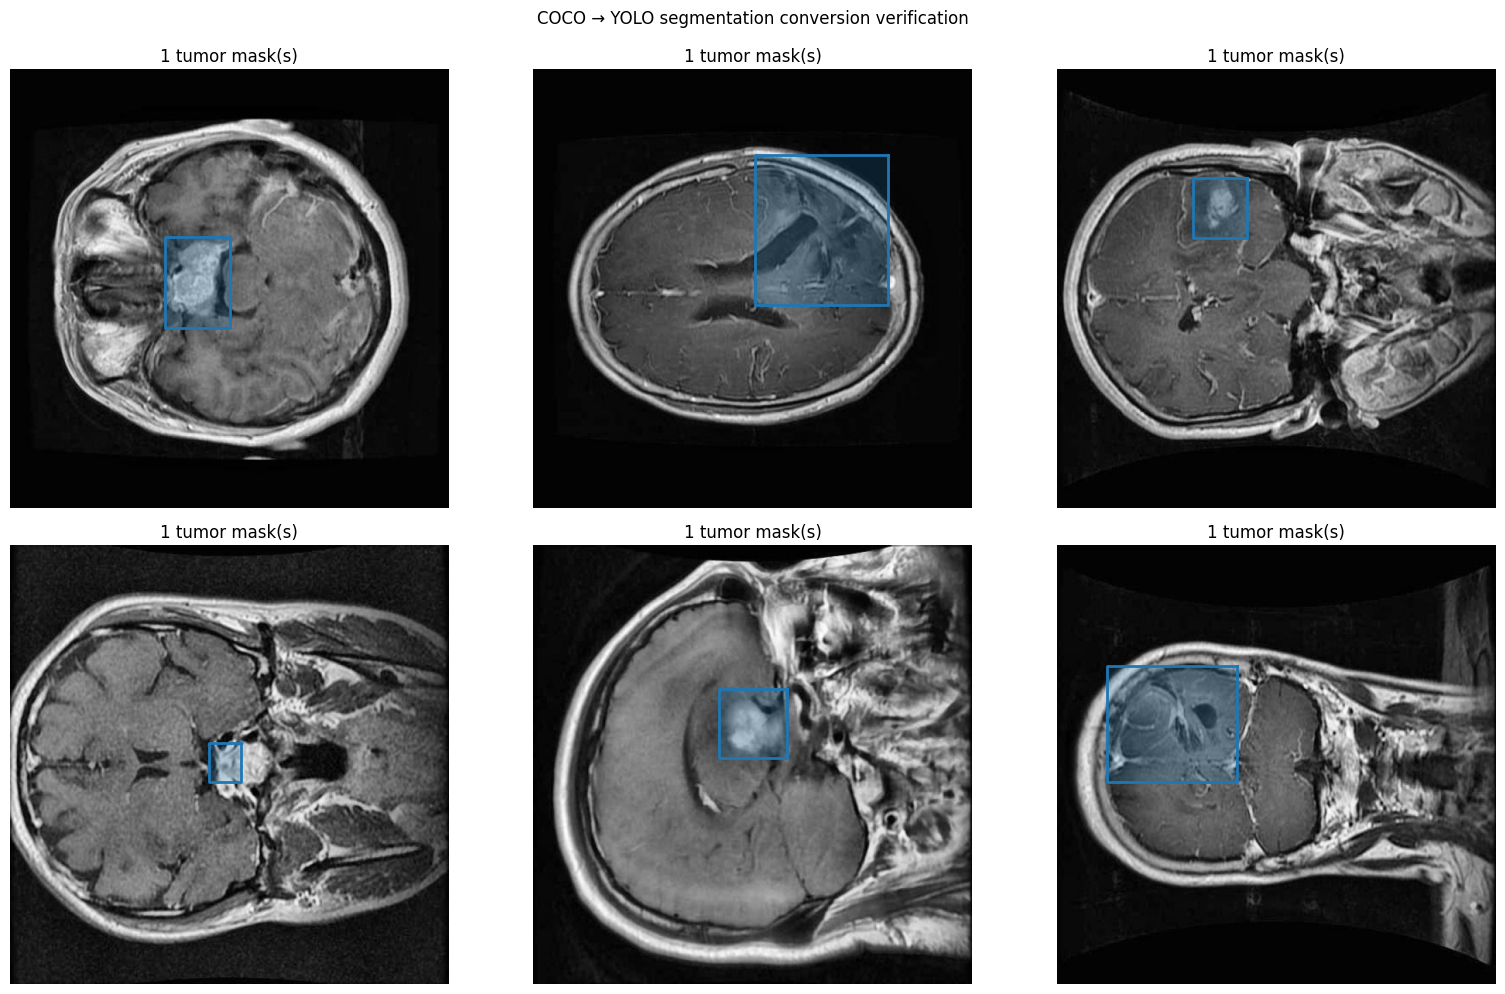

In [5]:
# Cell 5 — Visual verification of converted segmentation polygons
def read_yolo_segmentation_labels(label_path, image_width, image_height):
    instances = []
    for line in Path(label_path).read_text(encoding="utf-8").splitlines():
        parts = line.strip().split()
        if len(parts) < 7:
            continue

        class_id = int(parts[0])
        coordinates = np.asarray(parts[1:], dtype=np.float64).reshape(-1, 2)
        coordinates[:, 0] *= image_width
        coordinates[:, 1] *= image_height
        instances.append((class_id, coordinates))
    return instances


sample_rows = manifest[manifest["split"] == "train"].sample(
    min(6, (manifest["split"] == "train").sum()),
    random_state=cfg.seed,
)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = np.asarray(axes).reshape(-1)

for axis, (_, row) in zip(axes, sample_rows.iterrows()):
    image = Image.open(row["image_path"]).convert("RGB")
    instances = read_yolo_segmentation_labels(
        row["label_path"],
        *image.size,
    )

    axis.imshow(image)
    for class_id, polygon in instances:
        closed_polygon = np.vstack([polygon, polygon[0]])
        axis.plot(
            closed_polygon[:, 0],
            closed_polygon[:, 1],
            linewidth=2,
            label=class_names[class_id],
        )
        axis.fill(
            polygon[:, 0],
            polygon[:, 1],
            alpha=0.22,
        )

    axis.set_title(f"{len(instances)} tumor mask(s)")
    axis.axis("off")

for axis in axes[len(sample_rows):]:
    axis.axis("off")

plt.suptitle("COCO → YOLO segmentation conversion verification", y=0.99)
plt.tight_layout()
plt.show()


## 2. Stage A — BYOL pretraining

Two augmented MRI views are processed by an online network and a target network.

The online branch contains an encoder, projector, and predictor. The target branch contains an encoder and projector. The target branch receives no gradient and follows the online branch using exponential moving average.

Tumor masks and segmentation labels are not used during this stage.


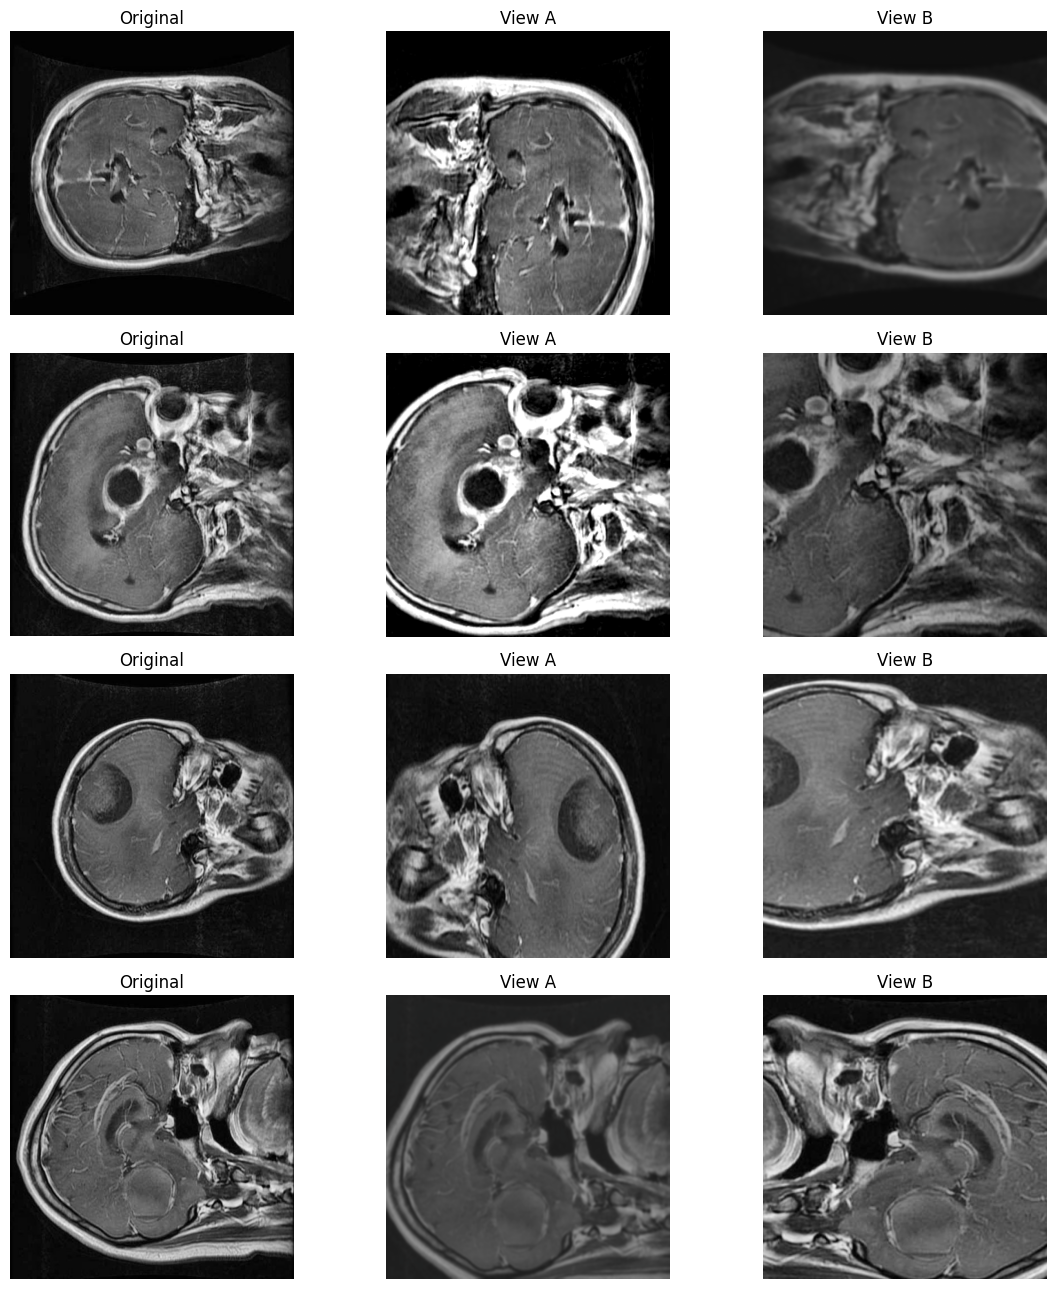

In [6]:
# Cell 6 — SimCLR datasets and augmentations
NORMALISATION_MEAN = (0.485, 0.456, 0.406)
NORMALISATION_STD = (0.229, 0.224, 0.225)

byol_transform = transforms.Compose([
    transforms.RandomResizedCrop(cfg.ssl_image_size, scale=(0.45, 1.00), antialias=True),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.40, contrast=0.40, saturation=0.35, hue=0.08)
    ], p=0.80),
    transforms.RandomGrayscale(p=0.15),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0))
    ], p=0.35),
    transforms.ToTensor(),
    transforms.Normalize(NORMALISATION_MEAN, NORMALISATION_STD),
])

evaluation_transform = transforms.Compose([
    transforms.Resize((cfg.ssl_image_size, cfg.ssl_image_size), antialias=True),
    transforms.ToTensor(),
    transforms.Normalize(NORMALISATION_MEAN, NORMALISATION_STD),
])

def denormalise(tensor):
    mean = torch.tensor(NORMALISATION_MEAN).view(3, 1, 1)
    std = torch.tensor(NORMALISATION_STD).view(3, 1, 1)
    return (tensor.detach().cpu() * std + mean).clamp(0, 1)


class BYOLImageDataset(Dataset):
    def __init__(self, image_paths, transform):
        self.image_paths = list(image_paths)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")
        return self.transform(image), self.transform(image)


class SingleViewDataset(Dataset):
    def __init__(self, frame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.loc[index]
        image = Image.open(row["image_path"]).convert("RGB")
        return evaluation_transform(image), int(row["number_of_masks"])


ssl_train_paths = manifest.loc[manifest["split"] == "train", "image_path"].tolist()
ssl_valid_paths = manifest.loc[manifest["split"] == "val", "image_path"].tolist()

ssl_train_dataset = BYOLImageDataset(ssl_train_paths, byol_transform)
ssl_valid_dataset = BYOLImageDataset(ssl_valid_paths, byol_transform)

loader_kwargs = {
    "num_workers": cfg.num_workers,
    "pin_memory": AMP_ENABLED,
}

if cfg.num_workers > 0:
    loader_kwargs["persistent_workers"] = cfg.persistent_workers
    loader_kwargs["prefetch_factor"] = cfg.prefetch_factor

ssl_train_loader = DataLoader(
    ssl_train_dataset,
    batch_size=cfg.ssl_batch_size,
    shuffle=True,
    drop_last=True,
    **loader_kwargs,
)
ssl_valid_loader = DataLoader(
    ssl_valid_dataset,
    batch_size=cfg.ssl_batch_size,
    shuffle=False,
    drop_last=False,
    **loader_kwargs,
)

fig, axes = plt.subplots(4, 3, figsize=(12, 13))
for row_index in range(min(4, len(ssl_train_dataset))):
    original = Image.open(ssl_train_paths[row_index]).convert("RGB")
    view_a, view_b = ssl_train_dataset[row_index]
    axes[row_index, 0].imshow(original)
    axes[row_index, 0].set_title("Original")
    axes[row_index, 1].imshow(denormalise(view_a).permute(1, 2, 0))
    axes[row_index, 1].set_title("View A")
    axes[row_index, 2].imshow(denormalise(view_b).permute(1, 2, 0))
    axes[row_index, 2].set_title("View B")
    for column in range(3):
        axes[row_index, column].axis("off")
plt.tight_layout()
plt.show()

In [7]:
# Cell 7 — YOLO26 graph-aware multi-scale feature extractor
yolo = YOLO(cfg.yolo_model)
segmentation_network = yolo.model.to(device)


class UltralyticsFeatureExtractor(nn.Module):
    def __init__(self, segmentation_model):
        super().__init__()
        self.segmentation_model = segmentation_model
        self.layers = segmentation_model.model
        self.detect_layer = self.layers[-1]
        self.feature_layers = self.layers[:-1]
        self.save = set(getattr(segmentation_model, "save", []))

    @staticmethod
    def route(layer, current, saved):
        source = layer.f
        if source == -1:
            return current
        if isinstance(source, int):
            return saved[source]
        return [current if index == -1 else saved[index] for index in source]

    def forward(self, images):
        saved = []
        current = images

        for layer in self.feature_layers:
            current = layer(self.route(layer, current, saved))
            saved.append(current if layer.i in self.save else None)

        sources = self.detect_layer.f
        if isinstance(sources, int):
            features = [current if sources == -1 else saved[sources]]
        else:
            features = [current if index == -1 else saved[index] for index in sources]

        if any(feature is None for feature in features):
            raise RuntimeError("Could not recover all feature maps consumed by the segmentation head.")
        return features


feature_extractor = UltralyticsFeatureExtractor(segmentation_network).to(device)

with torch.inference_mode():
    dummy = torch.zeros(2, 3, cfg.ssl_image_size, cfg.ssl_image_size, device=device)
    with amp_context():
        dummy_features = feature_extractor(dummy)

feature_shapes = [tuple(feature.shape) for feature in dummy_features]
pooled_dimension = sum(feature.shape[1] for feature in dummy_features)

print("Feature shapes:", feature_shapes)
print("Pooled dimension:", pooled_dimension)

Feature shapes: [(2, 64, 40, 40), (2, 128, 20, 20), (2, 256, 10, 10)]
Pooled dimension: 448


In [8]:
# ============================================================
# Cell 8: BYOL model with online and target YOLO26 encoders
# ============================================================
class MLPHead(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.SiLU(inplace=True),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.network(x)


class BYOLYOLO(nn.Module):
    """BYOL using YOLO26 multi-scale feature extractors."""

    def __init__(
        self,
        online_extractor,
        target_extractor,
        pooled_dimension,
        projection_hidden_dim,
        projection_dim,
        predictor_hidden_dim,
        ema_momentum,
    ):
        super().__init__()

        self.online_extractor = online_extractor
        self.target_extractor = target_extractor

        self.online_projector = MLPHead(
            pooled_dimension,
            projection_hidden_dim,
            projection_dim,
        )
        self.target_projector = MLPHead(
            pooled_dimension,
            projection_hidden_dim,
            projection_dim,
        )
        self.online_predictor = MLPHead(
            projection_dim,
            predictor_hidden_dim,
            projection_dim,
        )

        self.ema_momentum = float(ema_momentum)

        self.target_extractor.load_state_dict(
            self.online_extractor.state_dict()
        )
        self.target_projector.load_state_dict(
            self.online_projector.state_dict()
        )

        for parameter in self.target_extractor.parameters():
            parameter.requires_grad = False

        for parameter in self.target_projector.parameters():
            parameter.requires_grad = False

    @staticmethod
    def pool_multiscale(feature_maps):
        pooled = [
            F.adaptive_avg_pool2d(feature_map, 1).flatten(1)
            for feature_map in feature_maps
        ]
        return torch.cat(pooled, dim=1)

    def encode_online(self, images):
        feature_maps = self.online_extractor(images)
        features = self.pool_multiscale(feature_maps)
        projections = self.online_projector(features)
        predictions = self.online_predictor(projections)
        return features, projections, predictions

    @torch.no_grad()
    def encode_target(self, images):
        feature_maps = self.target_extractor(images)
        features = self.pool_multiscale(feature_maps)
        projections = self.target_projector(features)
        return features, projections

    @torch.no_grad()
    def update_target_network(self):
        for online_parameter, target_parameter in zip(
            self.online_extractor.parameters(),
            self.target_extractor.parameters(),
        ):
            target_parameter.data.mul_(self.ema_momentum).add_(
                online_parameter.data,
                alpha=1.0 - self.ema_momentum,
            )

        for online_parameter, target_parameter in zip(
            self.online_projector.parameters(),
            self.target_projector.parameters(),
        ):
            target_parameter.data.mul_(self.ema_momentum).add_(
                online_parameter.data,
                alpha=1.0 - self.ema_momentum,
            )


def byol_loss(prediction, target):
    prediction = F.normalize(prediction.float(), dim=1)
    target = F.normalize(target.detach().float(), dim=1)
    return 2.0 - 2.0 * (prediction * target).sum(dim=1).mean()


online_extractor = feature_extractor

target_segmentation_network = copy.deepcopy(
    segmentation_network
).to(device)

target_extractor = UltralyticsFeatureExtractor(
    target_segmentation_network
).to(device)

byol_model = BYOLYOLO(
    online_extractor=online_extractor,
    target_extractor=target_extractor,
    pooled_dimension=pooled_dimension,
    projection_hidden_dim=cfg.projection_hidden_dim,
    projection_dim=cfg.projection_dim,
    predictor_hidden_dim=cfg.predictor_hidden_dim,
    ema_momentum=cfg.ema_momentum,
).to(device)

if AMP_ENABLED and cfg.use_channels_last:
    byol_model = byol_model.to(
        memory_format=torch.channels_last
    )

if cfg.use_torch_compile and hasattr(torch, "compile"):
    try:
        byol_model = torch.compile(
            byol_model,
            mode="reduce-overhead",
        )
        print("torch.compile enabled.")
    except Exception as compile_error:
        print("torch.compile could not be enabled:", compile_error)

initial_feature_state = copy.deepcopy({
    key: value.detach().cpu()
    for key, value in byol_model.online_extractor.state_dict().items()
})

trainable_parameters = (
    list(byol_model.online_extractor.parameters())
    + list(byol_model.online_projector.parameters())
    + list(byol_model.online_predictor.parameters())
)

ssl_optimizer = torch.optim.AdamW(
    trainable_parameters,
    lr=cfg.ssl_learning_rate,
    weight_decay=cfg.ssl_weight_decay,
)

ssl_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    ssl_optimizer,
    T_max=max(1, cfg.ssl_epochs),
)

print("Projection dimension:", cfg.projection_dim)
print("EMA momentum:", cfg.ema_momentum)


Projection dimension: 256
EMA momentum: 0.996


In [9]:
# ============================================================
# Cell 9: Optimized BYOL training and validation
# ============================================================
import time


def move_to_device(images: torch.Tensor) -> torch.Tensor:
    images = images.to(
        device,
        non_blocking=AMP_ENABLED,
    )
    if AMP_ENABLED and cfg.use_channels_last:
        images = images.contiguous(
            memory_format=torch.channels_last
        )
    else:
        images = images.contiguous()
    return images


def run_byol_epoch(
    model,
    loader,
    optimizer=None,
    scaler=None,
    description="BYOL",
    update_target=True,
):
    training = optimizer is not None
    model.train(training)

    model.target_extractor.eval()
    model.target_projector.eval()

    total_loss = 0.0
    total_similarity = 0.0
    processed_batches = 0
    processed_images = 0
    start_time = time.perf_counter()

    progress = tqdm(
        loader,
        desc=description,
        dynamic_ncols=True,
        leave=False,
        unit="batch",
    )

    if training:
        optimizer.zero_grad(set_to_none=True)

    for batch_index, (view_one, view_two) in enumerate(
        progress,
        start=1,
    ):
        if view_one.size(0) < 2:
            continue

        view_one = move_to_device(view_one)
        view_two = move_to_device(view_two)

        with torch.set_grad_enabled(training):
            with amp_context():
                _, _, prediction_one = model.encode_online(view_one)
                _, _, prediction_two = model.encode_online(view_two)

                with torch.no_grad():
                    _, target_one = model.encode_target(view_one)
                    _, target_two = model.encode_target(view_two)

            loss_one = byol_loss(
                prediction_one,
                target_two,
            )
            loss_two = byol_loss(
                prediction_two,
                target_one,
            )
            loss = 0.5 * (loss_one + loss_two)

            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite BYOL loss detected.")

            scaled_loss = (
                loss / cfg.gradient_accumulation_steps
            )

            if training:
                if AMP_ENABLED:
                    scaler.scale(scaled_loss).backward()
                else:
                    scaled_loss.backward()

                should_step = (
                    batch_index
                    % cfg.gradient_accumulation_steps
                    == 0
                    or batch_index == len(loader)
                )

                if should_step:
                    if AMP_ENABLED:
                        scaler.unscale_(optimizer)

                    torch.nn.utils.clip_grad_norm_(
                        trainable_parameters,
                        max_norm=5.0,
                    )

                    if AMP_ENABLED:
                        scaler.step(optimizer)
                        scaler.update()
                    else:
                        optimizer.step()

                    optimizer.zero_grad(set_to_none=True)

                    if update_target:
                        model.update_target_network()

        with torch.no_grad():
            similarity = 1.0 - (loss / 2.0)

        batch_size = view_one.size(0)
        total_loss += float(loss.item())
        total_similarity += float(similarity.item())
        processed_batches += 1
        processed_images += batch_size

        elapsed = max(
            time.perf_counter() - start_time,
            1e-9,
        )
        throughput = processed_images / elapsed

        progress.set_postfix(
            loss=f"{total_loss / processed_batches:.4f}",
            sim=f"{total_similarity / processed_batches:.3f}",
            img_s=f"{throughput:.1f}",
            lr=(
                f"{optimizer.param_groups[0]['lr']:.2e}"
                if training
                else "validation"
            ),
        )

    if processed_batches == 0:
        raise ValueError("No valid BYOL batches were processed.")

    elapsed = time.perf_counter() - start_time

    return {
        "loss": total_loss / processed_batches,
        "similarity": total_similarity / processed_batches,
        "processed_images": processed_images,
        "elapsed_seconds": elapsed,
        "images_per_second": (
            processed_images / max(elapsed, 1e-9)
        ),
    }


view_one, view_two = next(iter(ssl_train_loader))
view_one = move_to_device(
    view_one[: min(4, len(view_one))]
)
view_two = move_to_device(
    view_two[: min(4, len(view_two))]
)

byol_model.train()

with torch.no_grad():
    with amp_context():
        _, _, prediction_one = byol_model.encode_online(view_one)
        _, target_two = byol_model.encode_target(view_two)

    smoke_loss = byol_loss(
        prediction_one,
        target_two,
    )

assert torch.isfinite(smoke_loss)

print(
    f"Smoke test passed | "
    f"loss={smoke_loss.item():.4f}"
)

ssl_records = []
best_ssl_loss = float("inf")
best_ssl_state = None
total_training_start = time.perf_counter()

epoch_progress = tqdm(
    range(1, cfg.ssl_epochs + 1),
    desc="Overall BYOL progress",
    dynamic_ncols=True,
    unit="epoch",
)

for epoch in epoch_progress:
    train_result = run_byol_epoch(
        byol_model,
        ssl_train_loader,
        optimizer=ssl_optimizer,
        scaler=SCALER,
        description=f"Train {epoch}/{cfg.ssl_epochs}",
        update_target=True,
    )

    with torch.inference_mode():
        valid_result = run_byol_epoch(
            byol_model,
            ssl_valid_loader,
            optimizer=None,
            description=f"Valid {epoch}/{cfg.ssl_epochs}",
            update_target=False,
        )

    ssl_scheduler.step()

    record = {
        "epoch": epoch,
        "train_loss": train_result["loss"],
        "valid_loss": valid_result["loss"],
        "train_similarity": train_result["similarity"],
        "valid_similarity": valid_result["similarity"],
        "train_images_per_second": (
            train_result["images_per_second"]
        ),
        "valid_images_per_second": (
            valid_result["images_per_second"]
        ),
        "train_elapsed_seconds": (
            train_result["elapsed_seconds"]
        ),
        "valid_elapsed_seconds": (
            valid_result["elapsed_seconds"]
        ),
        "learning_rate": (
            ssl_optimizer.param_groups[0]["lr"]
        ),
    }
    ssl_records.append(record)

    if valid_result["loss"] < best_ssl_loss:
        best_ssl_loss = valid_result["loss"]
        best_ssl_state = copy.deepcopy({
            key: value.detach().cpu()
            for key, value in byol_model.state_dict().items()
        })

    epoch_progress.set_postfix(
        train=f"{train_result['loss']:.4f}",
        valid=f"{valid_result['loss']:.4f}",
        best=f"{best_ssl_loss:.4f}",
        img_s=f"{train_result['images_per_second']:.1f}",
    )

total_training_seconds = (
    time.perf_counter() - total_training_start
)

if best_ssl_state is None:
    raise RuntimeError(
        "No valid BYOL checkpoint was produced."
    )

byol_model.load_state_dict(best_ssl_state)
byol_model.to(device)

ssl_history = pd.DataFrame(ssl_records)
ssl_history.to_csv(
    SSL_OUTPUT_DIR / "byol_history.csv",
    index=False,
)

torch.save(
    {
        "config": asdict(cfg),
        "class_names": class_names,
        "byol_state_dict": byol_model.state_dict(),
        "online_feature_state_dict": (
            byol_model.online_extractor.state_dict()
        ),
        "best_validation_loss": best_ssl_loss,
        "total_training_seconds": total_training_seconds,
    },
    SSL_OUTPUT_DIR / "byol_yolo26_checkpoint.pt",
)

display(ssl_history.round(4))

print(f"Best validation BYOL loss: {best_ssl_loss:.4f}")
print(
    f"Total SSL training time: "
    f"{total_training_seconds / 60:.2f} minutes"
)
print(
    "Average training throughput: "
    f"{ssl_history['train_images_per_second'].mean():.1f} "
    "images/second"
)


Smoke test passed | loss=2.0335


Overall BYOL progress:   0%|          | 0/5 [00:00<?, ?epoch/s]

Train 1/5:   0%|          | 0/93 [00:02<?, ?batch/s]

Valid 1/5:   0%|          | 0/27 [00:00<?, ?batch/s]

Train 2/5:   0%|          | 0/93 [00:00<?, ?batch/s]

...

Valid 4/5:   0%|          | 0/27 [00:00<?, ?batch/s]

Train 5/5:   0%|          | 0/93 [00:00<?, ?batch/s]

Valid 5/5:   0%|          | 0/27 [00:00<?, ?batch/s]

,epoch,train_loss,valid_loss,train_similarity,valid_similarity,train_images_per_second,valid_images_per_second,train_elapsed_seconds,valid_elapsed_seconds,learning_rate
0,1,0.1523,0.0002,0.9239,0.9999,15.3776,17.2946,96.7639,24.8054,0.0003
1,2,0.0003,0.0002,0.9999,0.9999,17.3055,14.3131,85.9841,29.9726,0.0002
2,3,0.0001,0.0001,0.9999,0.9999,16.4970,16.4860,90.1981,26.0221,0.0001
3,4,0.0001,0.0001,0.9999,1.0000,18.2724,14.8658,81.4344,28.8581,0.0000
4,5,0.0001,0.0001,0.9999,0.9999,17.8422,16.5431,83.3976,25.9322,0.0000


Best validation BYOL loss: 0.0001
Total SSL training time: 9.58 minutes
Average training throughput: 17.1 images/second


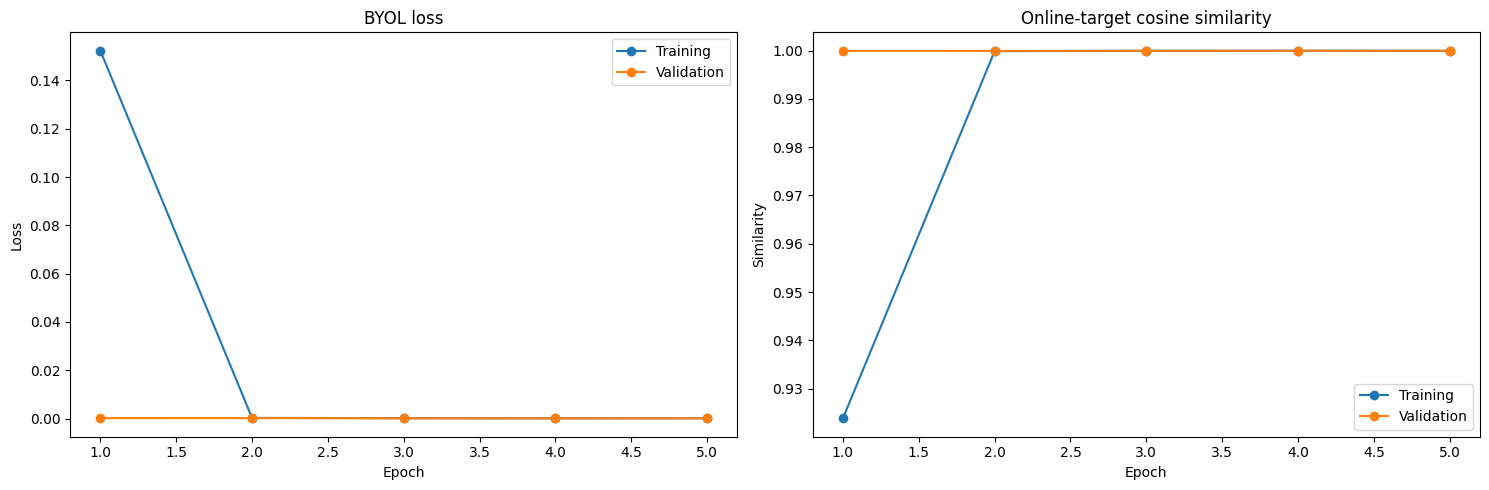

In [10]:
# ============================================================
# Cell 10: BYOL training diagnostics
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(
    ssl_history["epoch"],
    ssl_history["train_loss"],
    marker="o",
    label="Training",
)
axes[0].plot(
    ssl_history["epoch"],
    ssl_history["valid_loss"],
    marker="o",
    label="Validation",
)
axes[0].set_title("BYOL loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    ssl_history["epoch"],
    ssl_history["train_similarity"],
    marker="o",
    label="Training",
)
axes[1].plot(
    ssl_history["epoch"],
    ssl_history["valid_similarity"],
    marker="o",
    label="Validation",
)
axes[1].set_title("Online-target cosine similarity")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Similarity")
axes[1].legend()

plt.tight_layout()
plt.savefig(
    SSL_OUTPUT_DIR / "byol_training_curves.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()


## 3. Stage B — YOLO26 segmentation fine-tuning

The online YOLO26 encoder now contains the best BYOL-pretrained feature weights.

Before supervised training:

1. discard the target encoder;
2. discard both projectors;
3. discard the online predictor;
4. retain the online YOLO26 segmentation model;
5. fine-tune it using tumor polygon annotations.


In [11]:
# ============================================================
# Cell 11 — Save the BYOL-initialized YOLO26 segmenter and fine-tune
# ============================================================
ssl_initialized_path = WORKING_ROOT / "yolo26_seg_byol_initialized.pt"

# torch.compile wraps a model in OptimizedModule. Unwrap it when necessary.
trained_byol_model = (
    byol_model._orig_mod
    if hasattr(byol_model, "_orig_mod")
    else byol_model
)

# The online extractor contains the YOLO26 segmentation network whose
# backbone was updated during BYOL pretraining.
ssl_segmentation_model = (
    trained_byol_model
    .online_extractor
    .segmentation_model
)

# Create an independent CPU copy for an Ultralytics-compatible checkpoint.
checkpoint_model = copy.deepcopy(
    ssl_segmentation_model
).float().cpu()

# Re-enable gradients for supervised segmentation fine-tuning.
for parameter in checkpoint_model.parameters():
    parameter.requires_grad = True

checkpoint_model.eval()

checkpoint = {
    "model": checkpoint_model,
    "ema": None,
    "optimizer": None,
    "train_args": {},
    "epoch": -1,
    "best_fitness": None,
    "date": pd.Timestamp.utcnow().isoformat(),
    "version": ultralytics.__version__,
    "license": "AGPL-3.0",
}

torch.save(checkpoint, ssl_initialized_path)
print("BYOL-initialized checkpoint saved to:", ssl_initialized_path)

# Load the BYOL-initialized model and perform supervised fine-tuning.
segmenter = YOLO(str(ssl_initialized_path))
train_results = segmenter.train(
    data=str(data_yaml),
    epochs=cfg.segmentation_epochs,
    imgsz=cfg.segmentation_image_size,
    batch=cfg.segmentation_batch_size,
    workers=cfg.num_workers,
    patience=cfg.segmentation_patience,
    seed=cfg.seed,
    deterministic=True,
    pretrained=False,
    project=str(SEGMENTATION_PROJECT_DIR),
    name="byol_yolo26_seg",
    exist_ok=True,
    plots=True,
    verbose=True,
)

best_segmenter_path = Path(segmenter.trainer.best)
print("Best segmenter:", best_segmenter_path)


BYOL-initialized checkpoint saved to: /kaggle/working/cse445_byol_yolo26/yolo26_seg_byol_initialized.pt
Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/cse445_byol_yolo26/brain_tumor_yolo_seg/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/w

In [12]:
# Cell 12 — Held-out tumor-segmentation evaluation
best_segmenter = YOLO(str(best_segmenter_path))

test_metrics = best_segmenter.val(
    data=str(data_yaml),
    split="test",
    imgsz=cfg.segmentation_image_size,
    batch=cfg.segmentation_batch_size,
    workers=cfg.num_workers,
    plots=True,
    project=str(SEGMENTATION_PROJECT_DIR),
    name="byol_yolo26_seg_test",
    exist_ok=True,
)

metrics_frame = pd.DataFrame([
    {"metric": key, "value": float(value)}
    for key, value in test_metrics.results_dict.items()
])
metrics_frame.to_csv(WORKING_ROOT / "byol_yolo26_seg_test_metrics.csv", index=False)
display(metrics_frame)

Ultralytics 8.4.95 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,469 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1182.4±345.7 MB/s, size: 37.0 KB)
val: Scanning /kaggle/working/cse445_byol_yolo26/brain_tumor_yolo_seg/labels/test... 215 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 215/215 1.2Kit/s 0.2s
val: New cache created: /kaggle/working/cse445_byol_yolo26/brain_tumor_yolo_seg/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 27/27 6.2it/s 4.4s
                   all        215        215      0.472      0.497      0.474      0.242      0.482      0.503      0.479      0.245
                     0        118        118      0.452       0.22      0.235     0.0951       0.45      0.212      0.235     0.0941
                     1         97         97    

,metric,value
0,metrics/precision(B),0.472442
1,metrics/recall(B),0.496767
2,metrics/mAP50(B),0.473877
3,metrics/mAP50-95(B),0.241830
4,metrics/precision(M),0.481816
5,metrics/recall(M),0.502839
6,metrics/mAP50(M),0.478929
7,metrics/mAP50-95(M),0.245442
8,fitness,0.487273


Results saved to /kaggle/working/cse445_byol_yolo26/segmentation_runs/qualitative_segmentation_predictions


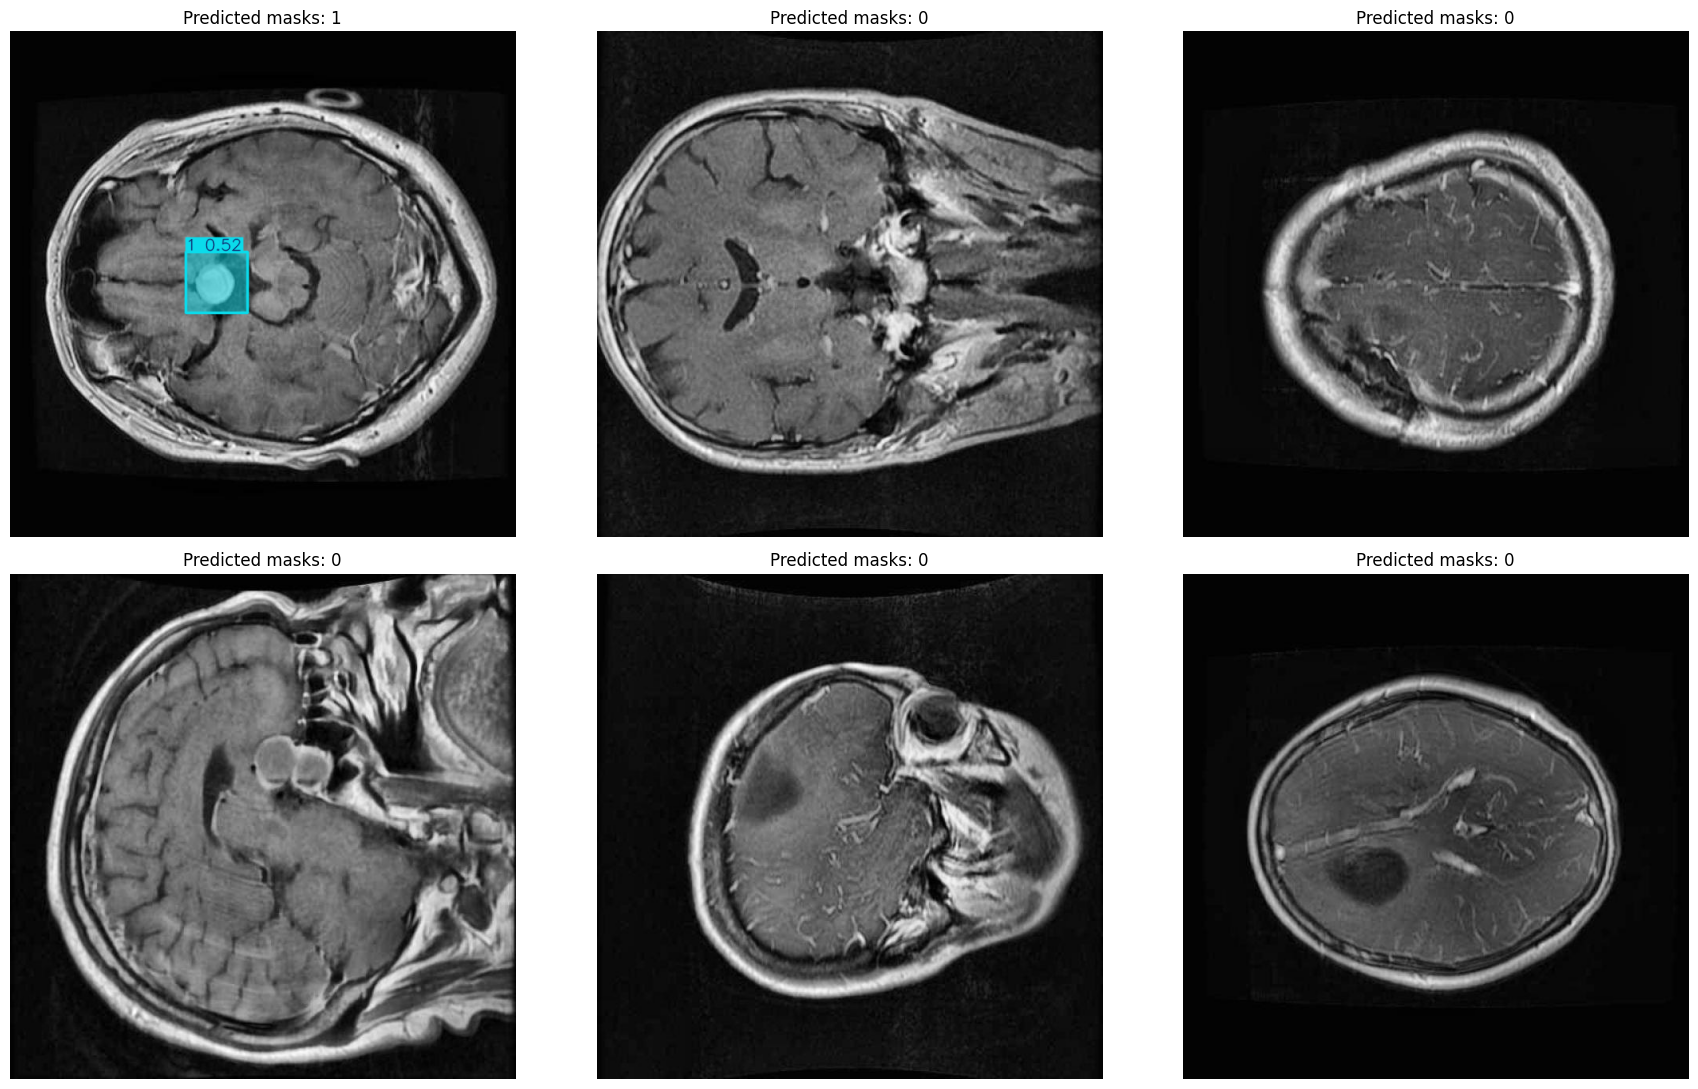

In [13]:
# Cell 13 — Qualitative tumor-mask predictions
test_images = manifest.loc[manifest["split"] == "test", "image_path"].sample(
    min(6, (manifest["split"] == "test").sum()),
    random_state=cfg.seed,
).tolist()

prediction_results = best_segmenter.predict(
    source=test_images,
    imgsz=cfg.segmentation_image_size,
    conf=0.25,
    iou=0.70,
    save=True,
    project=str(SEGMENTATION_PROJECT_DIR),
    name="qualitative_segmentation_predictions",
    exist_ok=True,
    verbose=False,
)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = np.asarray(axes).reshape(-1)

for axis, result in zip(axes, prediction_results):
    axis.imshow(result.plot()[:, :, ::-1])
    axis.set_title(f"Predicted masks: {0 if result.masks is None else len(result.masks.data)}")
    axis.axis("off")

for axis in axes[len(prediction_results):]:
    axis.axis("off")

plt.tight_layout()
plt.savefig(WORKING_ROOT / "qualitative_segmentation_predictions.png", dpi=220, bbox_inches="tight")
plt.show()

## 4. Representation analysis

The following t-SNE comparison visualizes pooled YOLO26 features before and after BYOL pretraining.

Samples are colored by the number of annotated tumor masks. This count is used only for interpretation.


Features:   0%|          | 0/27 [00:00<?, ?it/s]

Features:   0%|          | 0/27 [00:00<?, ?it/s]

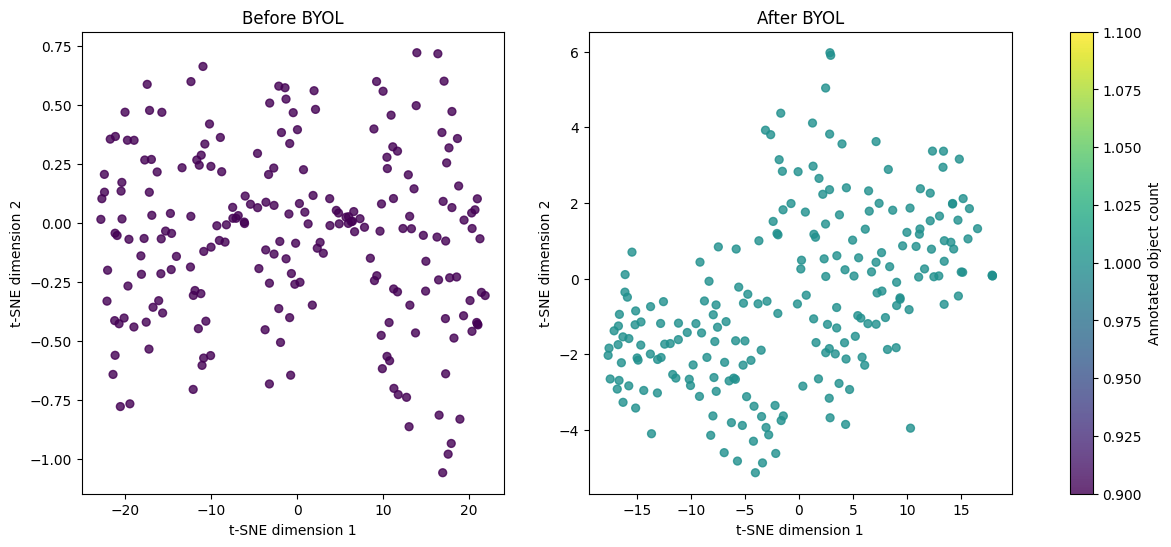

In [14]:
# Cell 14 — t-SNE before and after BYOL
feature_frame = manifest[manifest["split"] == "test"].copy()
if len(feature_frame) > cfg.tsne_max_samples:
    feature_frame = feature_frame.sample(cfg.tsne_max_samples, random_state=cfg.seed)

feature_loader = DataLoader(
    SingleViewDataset(feature_frame),
    batch_size=cfg.segmentation_batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=AMP_ENABLED,
)

def collect_features(extractor):
    extractor.eval()
    values, counts = [], []
    with torch.inference_mode():
        for images, mask_counts in tqdm(feature_loader, desc="Features", leave=False):
            images = move_to_device(images)
            with amp_context():
                maps = extractor(images)
                pooled = torch.cat([
                    F.adaptive_avg_pool2d(feature_map, 1).flatten(1)
                    for feature_map in maps
                ], dim=1)
            values.append(pooled.float().cpu().numpy())
            counts.append(mask_counts.numpy())
    return np.concatenate(values), np.concatenate(counts)

after_features, mask_counts = collect_features(byol_model.online_extractor)

ssl_feature_state = copy.deepcopy({
    key: value.detach().cpu()
    for key, value in byol_model.online_extractor.state_dict().items()
})
byol_model.online_extractor.load_state_dict(initial_feature_state)
byol_model.online_extractor.to(device)
before_features, _ = collect_features(byol_model.online_extractor)

byol_model.online_extractor.load_state_dict(ssl_feature_state)
byol_model.online_extractor.to(device)

sample_count = len(feature_frame)
perplexity = max(2, min(30, (sample_count - 1) // 3))

before_embedding = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=cfg.seed,
).fit_transform(before_features)

after_embedding = TSNE(
    n_components=2,
    perplexity=perplexity,
    init="pca",
    learning_rate="auto",
    random_state=cfg.seed,
).fit_transform(after_features)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, embedding, title in [
    (axes[0], before_embedding, "Before BYOL"),
    (axes[1], after_embedding, "After BYOL"),
]:
    scatter = axis.scatter(
        embedding[:, 0],
        embedding[:, 1],
        c=mask_counts,
        s=32,
        alpha=0.8,
    )
    axis.set_title(title)
    axis.set_xlabel("t-SNE dimension 1")
    axis.set_ylabel("t-SNE dimension 2")

fig.colorbar(scatter, ax=axes, label="Annotated object count")
plt.savefig(SSL_OUTPUT_DIR / "tsne_before_after_byol.png", dpi=220, bbox_inches="tight")
plt.show()

## Recommended comparative experiment

Compare random initialization, SimCLR, MoCo, and BYOL using identical YOLO26 segmentation settings and label fractions of 10%, 25%, 50%, and 100%.

Report mask precision, recall, mAP@0.50, mAP@0.50:0.95, Dice, IoU, latency, and mean ± standard deviation across at least three seeds.


In [15]:
# Cell 15 — Output summary
important_paths = [
    data_yaml,
    PREPARED_ROOT / "manifest.csv",
    SSL_OUTPUT_DIR / "byol_yolo26_checkpoint.pt",
    SSL_OUTPUT_DIR / "byol_history.csv",
    SSL_OUTPUT_DIR / "byol_training_curves.png",
    SSL_OUTPUT_DIR / "tsne_before_after_byol.png",
    WORKING_ROOT / "byol_yolo26_seg_test_metrics.csv",
    WORKING_ROOT / "qualitative_segmentation_predictions.png",
    best_segmenter_path,
]

print("Pipeline completed. Important artifacts:")
for path in important_paths:
    print(" -", path)

Pipeline completed. Important artifacts:
 - /kaggle/working/cse445_byol_yolo26/brain_tumor_yolo_seg/data.yaml
 - /kaggle/working/cse445_byol_yolo26/brain_tumor_yolo_seg/manifest.csv
 - /kaggle/working/cse445_byol_yolo26/ssl_outputs/byol_yolo26_checkpoint.pt
 - /kaggle/working/cse445_byol_yolo26/ssl_outputs/byol_history.csv
 - /kaggle/working/cse445_byol_yolo26/ssl_outputs/byol_training_curves.png
 - /kaggle/working/cse445_byol_yolo26/ssl_outputs/tsne_before_after_byol.png
 - /kaggle/working/cse445_byol_yolo26/byol_yolo26_seg_test_metrics.csv
 - /kaggle/working/cse445_byol_yolo26/qualitative_segmentation_predictions.png
 - /kaggle/working/cse445_byol_yolo26/segmentation_runs/byol_yolo26_seg/weights/best.pt


## Classroom interpretation guide

1. Verify the COCO-to-YOLO polygon conversion.
2. Confirm that both BYOL augmentations preserve MRI anatomy.
3. Explain why the target network receives no gradient.
4. Explain the EMA target update.
5. Observe whether online-target similarity increases.
6. Compare BYOL with SimCLR, MoCo, and random initialization.
7. Treat the short default run as a teaching demonstration.

### Common fixes

- **CUDA out of memory:** reduce SSL batch size or image size.
- **Non-finite loss:** reduce the learning rate and retain float32 loss calculation.
- **No valid batch:** ensure at least two images are present.
- **No annotation JSON:** verify `_annotations.coco.json`.
- **Unknown model YAML:** update Ultralytics and verify `yolo26n-seg.yaml`.
- **Representation collapse:** inspect feature variance and reduce EMA momentum if necessary.


## Optional ways to optimize the BYOL notebook further

### Data loading

```python
cfg.num_workers = 4
cfg.prefetch_factor = 4
cfg.persistent_workers = True
```

### Gradient accumulation

```python
cfg.ssl_batch_size = 8
cfg.gradient_accumulation_steps = 4
```

$$
B_{\mathrm{effective}}
=
B_{\mathrm{physical}}
\times
N_{\mathrm{accumulation}}.
$$

### EMA momentum

Typical values:

```python
cfg.ema_momentum = 0.99
cfg.ema_momentum = 0.996
cfg.ema_momentum = 0.999
```

A larger value makes the target network evolve more slowly.

### `torch.compile`

```python
cfg.use_torch_compile = True
```

### Image size

Use `224` for quick experiments and `320` or `384` for stronger spatial representations.

### Larger model

```python
cfg.yolo_model = "yolo26s-seg.yaml"
```

### Recommended safe Kaggle configuration

```python
cfg.ssl_batch_size = 16
cfg.gradient_accumulation_steps = 1
cfg.ema_momentum = 0.996
cfg.num_workers = 2
cfg.prefetch_factor = 2
cfg.persistent_workers = True
cfg.use_channels_last = True
cfg.use_torch_compile = False
```
